# Employee Salary Prediction
## MIS444 - Predictive Analytics in Business

**Problem type:** Regression  
**Target variable:** `Salary` (continuous numerical outcome)  
**Dataset:** Employee Salary Dataset
**Source:** [Kaggle - Employee Salary Dataset](https://www.kaggle.com/datasets/anninasimon/employee-salary-dataset)

**Student name:** *Sayma Akhter*  
**Student ID:** *22204184*  


### Business problem
Employee compensation decisions should be consistent, explainable, and supported by evidence. This project develops regression models to estimate salary from job-related and employee characteristics. HR teams can use the analysis as a decision-support benchmark for compensation review; it should not replace human judgment or lawful pay-equity review.

### Project objectives
1. Clean and transform the employee dataset.
2. Explore salary patterns through descriptive statistics and visualizations.
3. select useful predictors without using identifiers.
4. Train and compare multiple regression algorithms.
5. Optimize tree-based models with cross-validation.
6. Evaluate models using MAE, MAPE, MSE, RMSE, and R-squared.
7. Translate model results into HR recommendations, limitations, and future improvements.

### Notebook outline
1. Data collection and understanding
2. Data preprocessing
3. Exploratory data analysis (EDA)
4. Feature selection
5. Model building and comparison
6. Model optimization
7. Evaluation and validation
8. Business insights and recommendations
9. Conclusion

---
## 1. Data Collection and Understanding

The dataset was downloaded from Kaggle as required by the project brief. Each row represents one employee. `Salary` is a numerical variable, so this is a regression problem.

### Data dictionary

| Variable | Type | Meaning | Modeling role |
|---|---|---|---|
| Employee_ID | Numeric identifier | Unique employee number | Excluded |
| Name | Text identifier | Employee name | Excluded |
| Age | Numeric | Employee age in years | Predictor |
| Gender | Categorical | Recorded gender | Predictor, interpreted cautiously |
| Department | Categorical | Business department | Predictor |
| Job_Title | Categorical | Employee's job title | Predictor |
| Experience_Years | Numeric | Total work experience | Predictor |
| Education_Level | Categorical | Highest education level | Predictor |
| Location | Categorical | Work location | Predictor |
| Salary | Numeric | Employee salary | **Target** |



In [ ]:
# 1.1 Import required libraries
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

print('Libraries imported successfully.')
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import cross_validate
from matplotlib.ticker import FuncFormatter
pd.set_option('display.max_colwidth', None)


Libraries imported successfully.


In [ ]:
# 1.2 Load the CSV file (works in Google Colab and in a local folder)
candidate_paths = [
    'employee_data.csv',
    'Employers_data.csv',
    'Employers_data(1).csv',
    'upload/Employers_data(1).csv',   # workspace verification fallback
    '../upload/Employers_data(1).csv'  # local verification fallback
]

file_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if file_path is None:
    try:
        from google.colab import files
        print('Please choose the employee CSV file from your computer.')
        uploaded = files.upload()
        file_path = next(iter(uploaded))
    except Exception as exc:
        raise FileNotFoundError(
            'CSV not found. Upload the file to Colab and run this cell again.'
        ) from exc

employee_raw = pd.read_csv(file_path)
employee = employee_raw.copy()

print(f'Loaded file: {file_path}')
print(f'Dataset shape: {employee.shape[0]:,} rows x {employee.shape[1]} columns')
display(employee.head())

Loaded file: Employers_data.csv
Dataset shape: 10,000 rows x 10 columns


,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [ ]:
# 1.3 Inspect structure, data types, and unique values
print('Column names:')
print(employee.columns.tolist())
print('\nData types and non-null counts:')
employee.info()

print('\nUnique values per column:')
display(employee.nunique().rename('Unique_Count').to_frame())

Column names:
['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location', 'Salary']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB

Unique values per column:


,Unique_Count
Employee_ID,10000
Name,9868
Age,40
Gender,2
Department,6
Job_Title,5
Experience_Years,38
Education_Level,3
Location,5
Salary,39


In [ ]:
# 1.4 Descriptive statistics
print('Numerical summary:')
display(employee.describe().T)

print('Categorical summary:')
display(employee.describe(include='object').T)

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Employee_ID,10000.0,5000.5000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Age,10000.0,35.4559,10.000213,21.0,27.00,34.0,43.00,60.0
Experience_Years,10000.0,12.3709,9.148951,0.0,5.00,10.0,19.00,37.0
Salary,10000.0,115381.5000,46066.139047,25000.0,70000.00,120000.0,150000.00,215000.0


Categorical summary:


,count,unique,top,freq
Name,10000,9868,James Smith,5
Gender,10000,2,Male,5108
Department,10000,6,Product,1724
Job_Title,10000,5,Manager,3325
Education_Level,10000,3,Master,4930
Location,10000,5,Austin,2034


---
## 2. Data Preprocessing

The required preprocessing checks are performed explicitly: column-name cleaning, missing values, duplicates, invalid values, outliers, identifier removal, encoding, imputation, and scaling. Importantly, preprocessing is fitted on the training set only to prevent data leakage.

In [ ]:
# 2.1 Standardize column names and verify required columns
employee.columns = (
    employee.columns.str.strip()
    .str.replace(r'[^A-Za-z0-9]+', '_', regex=True)
    .str.strip('_')
)

required_columns = {
    'Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title',
    'Experience_Years', 'Education_Level', 'Location', 'Salary'
}
missing_columns = required_columns - set(employee.columns)
assert not missing_columns, f'Required columns are missing: {sorted(missing_columns)}'

print('Standardized columns:')
print(employee.columns.tolist())

Standardized columns:
['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location', 'Salary']


In [ ]:
# 2.2 Missing-value check
missing_table = pd.DataFrame({
    'Missing_Count': employee.isna().sum(),
    'Missing_Percent': (employee.isna().mean() * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

display(missing_table)
print(f'Total missing cells: {int(employee.isna().sum().sum()):,}')

missing_nonzero = missing_table[missing_table['Missing_Count'] > 0]
if missing_nonzero.empty:
    print('Result: No missing values were found. The modeling pipeline still contains safe imputers.')
else:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_nonzero.index, y=missing_nonzero['Missing_Count'], color='tomato')
    plt.xticks(rotation=45, ha='right')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

,Missing_Count,Missing_Percent
Employee_ID,0,0.0
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Department,0,0.0
Job_Title,0,0.0
Experience_Years,0,0.0
Education_Level,0,0.0
Location,0,0.0
Salary,0,0.0


Total missing cells: 0
Result: No missing values were found. The modeling pipeline still contains safe imputers.


In [ ]:
# 2.3 Duplicate-row check and treatment
duplicate_count = int(employee.duplicated().sum())
print(f'Exact duplicate rows found: {duplicate_count:,}')

if duplicate_count > 0:
    employee = employee.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. New shape: {employee.shape}')
else:
    print('No exact duplicates needed removal.')

# Names may repeat naturally, so repeated names alone are not treated as duplicate employees.
print(f'Repeated Name values (not automatically removed): {employee["Name"].duplicated().sum():,}')

Exact duplicate rows found: 0
No exact duplicates needed removal.
Repeated Name values (not automatically removed): 132


In [ ]:
# 2.4 Validity and consistency checks
numeric_validity = pd.DataFrame({
    'Minimum': employee[['Age', 'Experience_Years', 'Salary']].min(),
    'Maximum': employee[['Age', 'Experience_Years', 'Salary']].max(),
    'Negative_Count': (employee[['Age', 'Experience_Years', 'Salary']] < 0).sum()
})
display(numeric_validity)

print('Categorical values:')
for col in ['Gender', 'Department', 'Job_Title', 'Education_Level', 'Location']:
    print(f'\n{col}: {sorted(employee[col].dropna().astype(str).unique())}')

# A logical consistency check: experience should not be greater than age.
logical_issues = int((employee['Experience_Years'] > employee['Age']).sum())
print(f'\nRows where Experience_Years > Age: {logical_issues}')

,Minimum,Maximum,Negative_Count
Age,21,60,0
Experience_Years,0,37,0
Salary,25000,215000,0


Categorical values:

Gender: ['Female', 'Male']

Department: ['Engineering', 'Finance', 'HR', 'Marketing', 'Product', 'Sales']

Job_Title: ['Analyst', 'Engineer', 'Executive', 'Intern', 'Manager']

Education_Level: ['Bachelor', 'Master', 'PhD']

Location: ['Austin', 'Chicago', 'New York', 'San Francisco', 'Seattle']

Rows where Experience_Years > Age: 0


,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,Age,27.0,43.0,3.0,67.0,0,0.0
1,Experience_Years,5.0,19.0,-16.0,40.0,0,0.0
2,Salary,70000.0,150000.0,-50000.0,270000.0,0,0.0


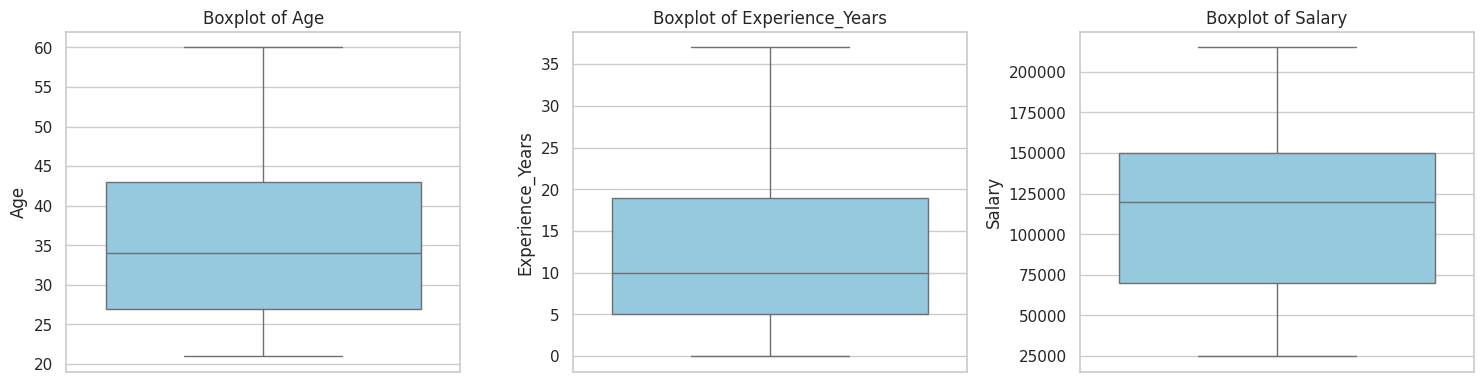

Result: No IQR outliers were detected, so no observations were deleted or capped.


In [ ]:
# 2.5 IQR outlier detection for numerical variables
def iqr_report(data, columns):
    rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((data[col] < lower) | (data[col] > upper)).sum())
        rows.append([col, q1, q3, lower, upper, count, count / len(data) * 100])
    return pd.DataFrame(rows, columns=[
        'Variable', 'Q1', 'Q3', 'Lower_Bound', 'Upper_Bound',
        'Outlier_Count', 'Outlier_Percent'
    ])

outlier_summary = iqr_report(employee, ['Age', 'Experience_Years', 'Salary'])
display(outlier_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Experience_Years', 'Salary']):
    sns.boxplot(y=employee[col], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

if outlier_summary['Outlier_Count'].sum() == 0:
    print('Result: No IQR outliers were detected, so no observations were deleted or capped.')
else:
    print('Potential outliers were retained unless clearly invalid; tree models are robust to unusual values.')

### Preprocessing decision

- `Employee_ID` and `Name` are removed because they identify individuals but do not explain salary.
- The raw dataset contains no missing cells, exact duplicate rows, or IQR outliers. These results are reported rather than artificially creating problems.
- Numerical predictors are median-imputed and standardized.
- Categorical predictors are mode-imputed and one-hot encoded.
- The train/test split is performed before fitting transformations, preventing information from the test set from leaking into training.

In [ ]:
# 2.6 Define predictors (X) and target (y); remove identifiers
identifier_columns = ['Employee_ID', 'Name']
target = 'Salary'

X = employee.drop(columns=identifier_columns + [target])
y = employee[target].astype(float)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print('Excluded identifier columns:', identifier_columns)
print('Numerical predictors:', numeric_features)
print('Categorical predictors:', categorical_features)
print('Target:', target)

Excluded identifier columns: ['Employee_ID', 'Name']
Numerical predictors: ['Age', 'Experience_Years']
Categorical predictors: ['Gender', 'Department', 'Job_Title', 'Education_Level', 'Location']
Target: Salary


In [ ]:
# 2.7 Split into training and test sets (80% / 20%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training rows: {len(X_train_raw):,} ({len(X_train_raw)/len(X):.0%})')
print(f'Testing rows : {len(X_test_raw):,} ({len(X_test_raw)/len(X):.0%})')
print('Index overlap:', len(set(X_train_raw.index) & set(X_test_raw.index)))

Training rows: 8,000 (80%)
Testing rows : 2,000 (20%)
Index overlap: 0


In [ ]:
# 2.8 Build and fit the preprocessing transformer on TRAINING DATA ONLY
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# DataFrame output preserves readable feature names inside every CV fold.
preprocessor.set_output(transform='pandas')
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

print('Processed training shape:', X_train_processed.shape)
print('Processed testing shape :', X_test_processed.shape)
print('Missing values after transformation:', int(X_train_processed.isna().sum().sum()))

Processed training shape: (8000, 23)
Processed testing shape : (2000, 23)
Missing values after transformation: 0


---
## 3. Exploratory Data Analysis (EDA)

EDA is conducted on the cleaned dataset to understand distributions, group differences, and relationships with salary. These plots describe association, not causation.

### 3.1A Histograms of numerical predictors
Following the faculty sample, inspect the distribution of each meaningful numerical
predictor. `Employee_ID` is excluded because its numerical values are identifiers.
`Salary` is examined separately in Section 3.1B immediately below.

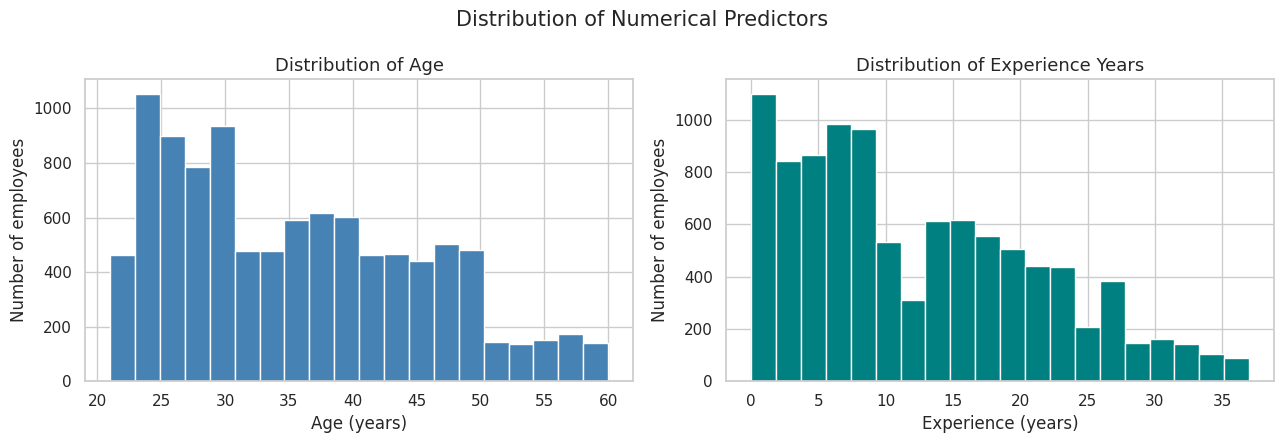

,Age,Experience_Years
min,21.000,0.000
median,34.000,10.000
max,60.000,37.000
skew,0.495,0.594


In [ ]:
# Histograms of Age and Experience_Years
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, column, color in zip(axes, ['Age', 'Experience_Years'], ['steelblue', 'teal']):
    ax.hist(employee[column], bins=20, color=color, edgecolor='white')
    ax.set_title(f'Distribution of {column.replace("_", " ")}', fontsize=13)
    ax.set_xlabel('Age (years)' if column == 'Age' else 'Experience (years)')
    ax.set_ylabel('Number of employees')
fig.suptitle('Distribution of Numerical Predictors', fontsize=15)
plt.tight_layout()
plt.show()
display(employee[['Age', 'Experience_Years']].agg(['min', 'median', 'max', 'skew']).round(3))

**Interpretation:** The histograms show which ages and experience levels are most
represented, rather than their relationship with salary. Fewer observations at an
extreme can mean less reliable predictions for that group. A skewed predictor is
not, by itself, a reason to remove observations or apply a log transformation.

### 3.1B Salary distribution

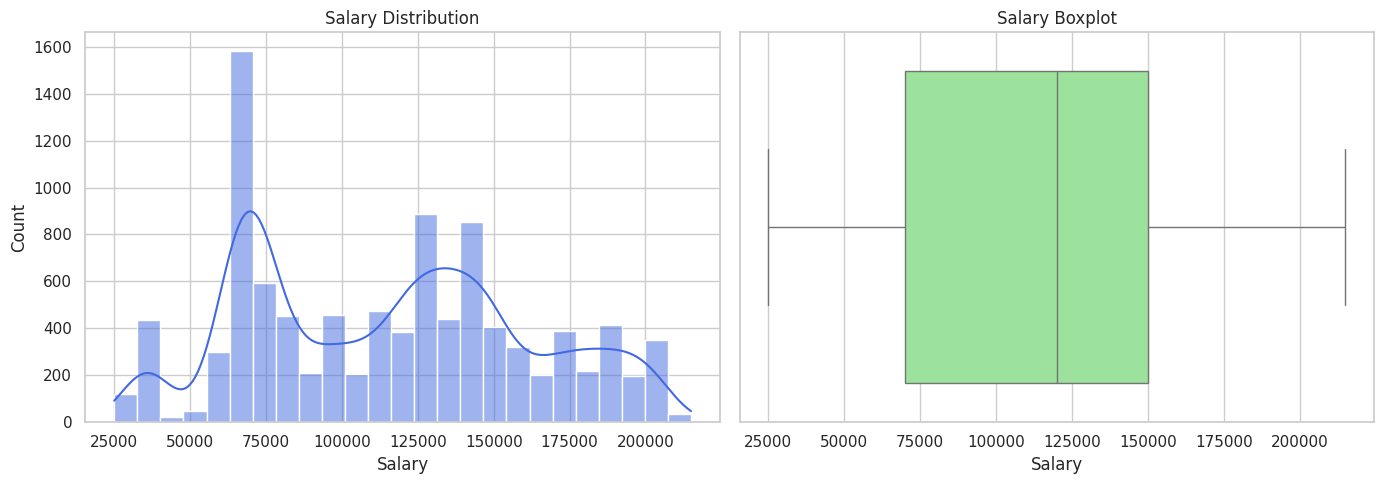

Mean salary  : 115,381.50
Median salary: 120,000.00
Skewness     : 0.145


In [ ]:
# 3.1 Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(employee['Salary'], bins=25, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Salary Distribution')
axes[0].set_xlabel('Salary')

sns.boxplot(x=employee['Salary'], ax=axes[1], color='lightgreen')
axes[1].set_title('Salary Boxplot')
axes[1].set_xlabel('Salary')
plt.tight_layout()
plt.show()

print(f'Mean salary  : {employee["Salary"].mean():,.2f}')
print(f'Median salary: {employee["Salary"].median():,.2f}')
print(f'Skewness     : {employee["Salary"].skew():.3f}')

**Interpretation:** The salary distribution shows the overall pay range and whether values are concentrated at particular levels. Comparing the mean and median helps identify skewness, while the boxplot verifies that extreme salaries are not dominating the analysis.

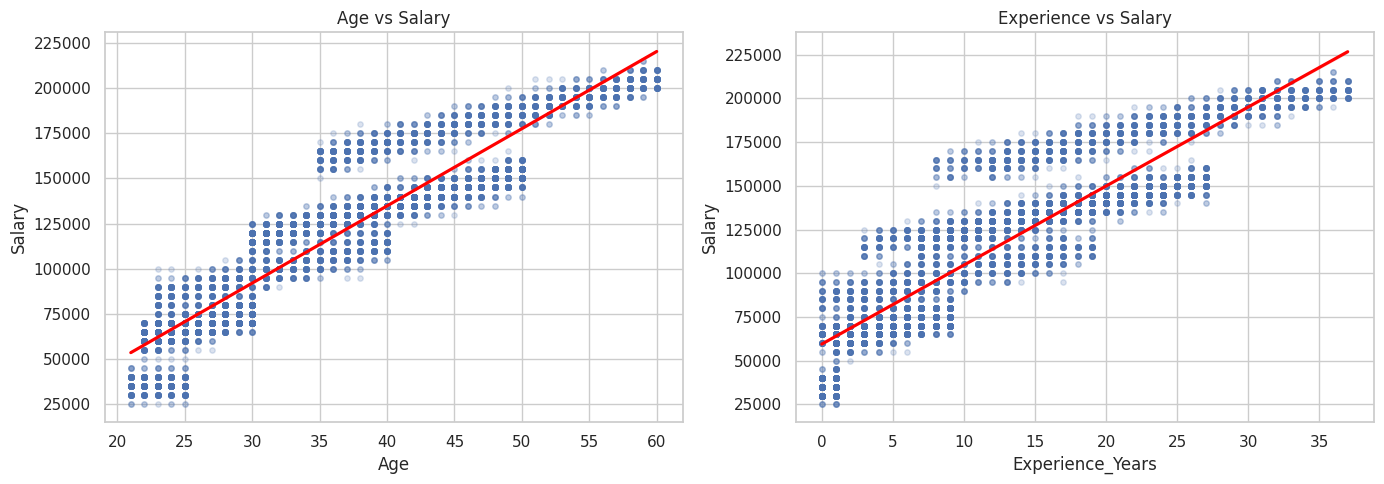

In [ ]:
# 3.2 Numerical predictors and salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=employee, x='Age', y='Salary', scatter_kws={'alpha': 0.20, 's': 15},
            line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('Age vs Salary')

sns.regplot(data=employee, x='Experience_Years', y='Salary',
            scatter_kws={'alpha': 0.20, 's': 15}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Experience vs Salary')
plt.tight_layout()
plt.show()

**Interpretation:** Salary generally rises with age and experience in this dataset. Age and experience also move together strongly, so their individual coefficients must be interpreted carefully because correlation between predictors can make linear effects difficult to separate.

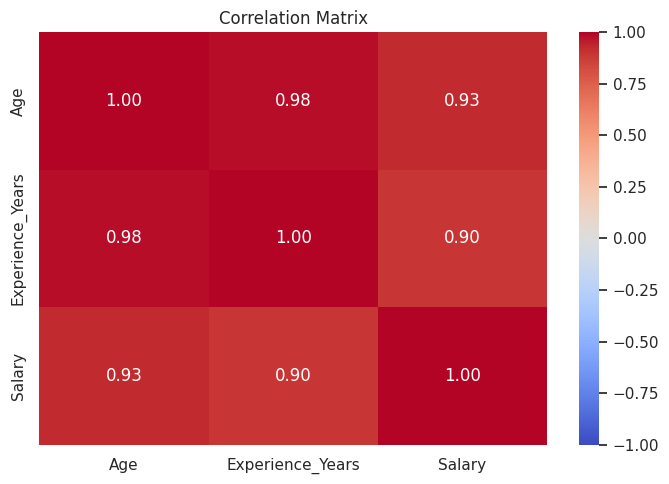

In [ ]:
# 3.3 Correlation heatmap for numerical variables
numeric_for_eda = employee[['Age', 'Experience_Years', 'Salary']]
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_for_eda.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

,index,Job_Title,count,mean,median
2,2,Executive,1921,183414.89,185000.0
4,4,Manager,3325,135260.15,135000.0
1,1,Engineer,1375,99272.73,100000.0
0,0,Analyst,2799,69478.39,70000.0
3,3,Intern,580,35801.72,35000.0


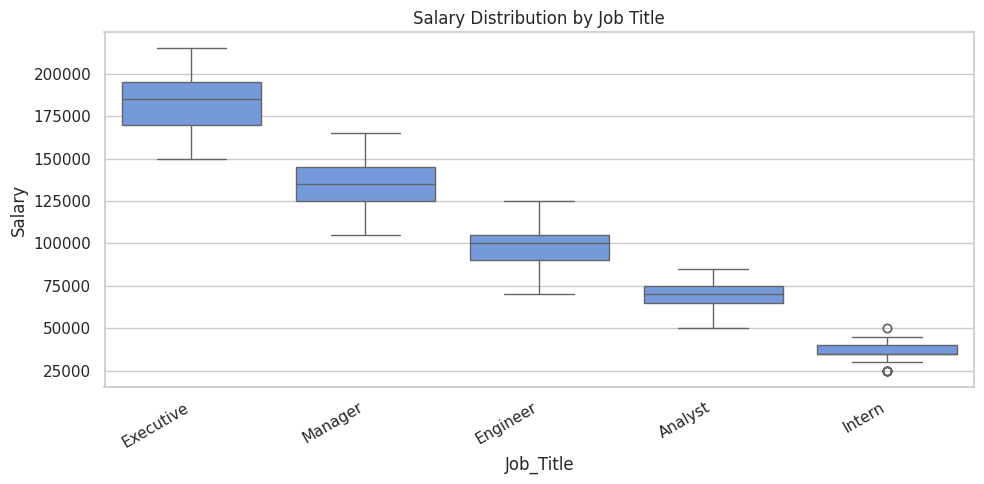

In [ ]:
# 3.4 Average salary by job title
salary_by_job = (
    employee.groupby('Job_Title', as_index=False)['Salary']
    .agg(['count', 'mean', 'median'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
display(salary_by_job.round(2))

plt.figure(figsize=(10, 5))
order = employee.groupby('Job_Title')['Salary'].median().sort_values(ascending=False).index
sns.boxplot(data=employee, x='Job_Title', y='Salary', order=order, color='cornflowerblue')
plt.title('Salary Distribution by Job Title')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** Job title produces clear differences in salary levels. Executive and managerial roles are expected to have higher pay bands than analyst and intern roles, making job title a likely key predictor.

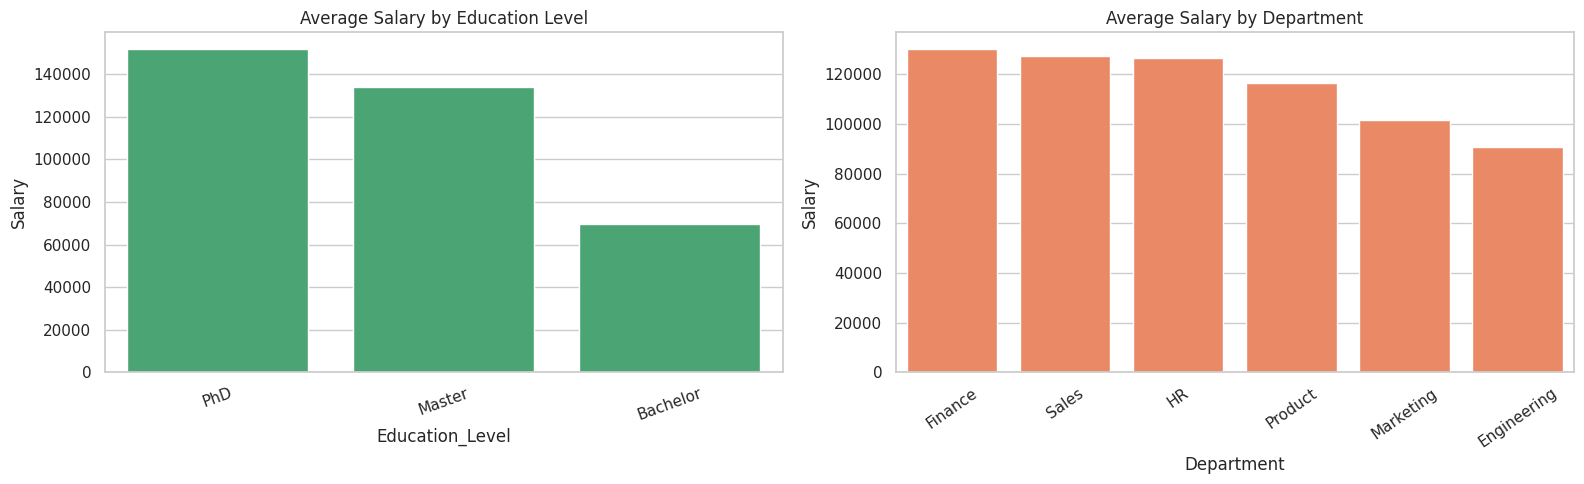

In [ ]:
# 3.5 Average salary by education level and department
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

edu_order = employee.groupby('Education_Level')['Salary'].mean().sort_values(ascending=False).index
sns.barplot(data=employee, x='Education_Level', y='Salary', order=edu_order,
            estimator=np.mean, errorbar=None, ax=axes[0], color='mediumseagreen')
axes[0].set_title('Average Salary by Education Level')
axes[0].tick_params(axis='x', rotation=20)

dept_order = employee.groupby('Department')['Salary'].mean().sort_values(ascending=False).index
sns.barplot(data=employee, x='Department', y='Salary', order=dept_order,
            estimator=np.mean, errorbar=None, ax=axes[1], color='coral')
axes[1].set_title('Average Salary by Department')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

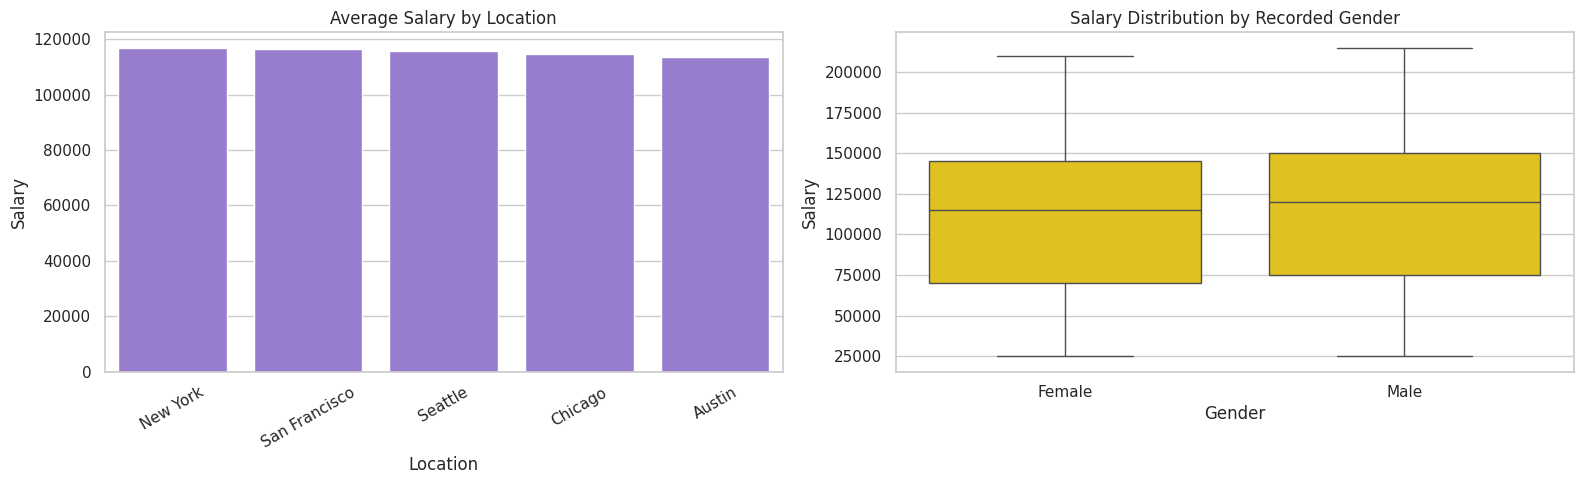

,count,mean,median
Gender,,,
Female,4892,114567.66,115000.0
Male,5108,116160.92,120000.0


This descriptive comparison does not prove discrimination or causation; role, experience, location, and other factors must be controlled.


In [ ]:
# 3.6 Salary by location and recorded gender (descriptive fairness check)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_order = employee.groupby('Location')['Salary'].mean().sort_values(ascending=False).index
sns.barplot(data=employee, x='Location', y='Salary', order=loc_order,
            estimator=np.mean, errorbar=None, ax=axes[0], color='mediumpurple')
axes[0].set_title('Average Salary by Location')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=employee, x='Gender', y='Salary', ax=axes[1], color='gold')
axes[1].set_title('Salary Distribution by Recorded Gender')

plt.tight_layout()
plt.show()

gender_summary = employee.groupby('Gender')['Salary'].agg(['count', 'mean', 'median']).round(2)
display(gender_summary)
print('This descriptive comparison does not prove discrimination or causation; role, experience, location, and other factors must be controlled.')

---
## 4. Feature Selection

This section follows the faculty sample's three-part approach:
1. **Pearson correlation with Salary:** signed linear associations, ranked by absolute magnitude.
2. **Random Forest feature importance:** predictive contributions in a nonlinear model.
3. **Final selection:** the overlap of the two rankings, with explicit HR relevance checks.

All tables below use **training rows only**. Numerical predictors are standardized;
categories are one-hot encoded, not assigned arbitrary numerical labels. Pearson
correlation of a 0/1 indicator with Salary compares that category against the rest;
it is not a causal effect. Random Forest importance is also not causal and can favor
continuous variables or split importance between correlated predictors.

The top-15 overlap rule is a classroom heuristic matching the sample, not proof that
other variables are useless. Keep all indicators of a retained categorical variable
so its categories are treated consistently. Job title and experience are retained as
core HR benchmarks even if a particular indicator misses the overlap. Gender is
reserved for descriptive auditing, not used to set pay. Age may remain if supported
by both rankings, but requires particular caution in any real-world HR use.

In [ ]:
# Reusable selection rule: refitted from scratch in each cross-validation fold.
class HRFeatureSelector(TransformerMixin, BaseEstimator):
    def __init__(self, top_k=15, n_estimators=100, random_state=42):
        self.top_k = top_k
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        # y is aligned by ROW POSITION with the fold's X, avoiding index mismatch.
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        target_series = pd.Series(np.asarray(y), index=X.index, name='Salary')
        corr = X.corrwith(target_series).fillna(0.0)
        self.pearson_table_ = pd.DataFrame({
            'Feature': corr.index, 'Pearson_r': corr.values,
            'Absolute_r': np.abs(corr.values)
        }).sort_values(['Absolute_r', 'Feature'], ascending=[False, True]).reset_index(drop=True)
        self.pearson_table_.insert(0, 'Pearson_Rank', np.arange(1, len(corr) + 1))

        self.forest_ = RandomForestRegressor(
            n_estimators=self.n_estimators, max_depth=12,
            random_state=self.random_state, n_jobs=1
        )
        self.forest_.fit(X, y)
        self.rf_table_ = pd.DataFrame({
            'Feature': X.columns, 'RF_Importance': self.forest_.feature_importances_
        }).sort_values(['RF_Importance', 'Feature'], ascending=[False, True]).reset_index(drop=True)
        self.rf_table_.insert(0, 'RF_Rank', np.arange(1, X.shape[1] + 1))

        k = min(self.top_k, X.shape[1])
        pearson_top = set(self.pearson_table_.head(k)['Feature'])
        rf_top = set(self.rf_table_.head(k)['Feature'])
        self.common_features_ = sorted(pearson_top & rf_top)

        def original_variable(name):
            if name.startswith('num__'):
                return name.removeprefix('num__')
            for variable in ['Gender', 'Department', 'Job_Title', 'Education_Level', 'Location']:
                if name.startswith('cat__' + variable + '_'):
                    return variable
            raise ValueError('Unrecognized feature: ' + name)

        common_variables = {original_variable(f) for f in self.common_features_}
        core_hr = {'Job_Title', 'Experience_Years'}
        retained_variables = (common_variables | core_hr) - {'Gender'}
        self.selected_features_ = [
            f for f in X.columns if original_variable(f) in retained_variables
        ]
        self.retained_variables_ = sorted(retained_variables)

        decision = self.pearson_table_.merge(self.rf_table_, on='Feature')
        decision['Original_Predictor'] = decision['Feature'].map(original_variable)
        decision['In_both_top15'] = decision['Feature'].isin(self.common_features_)
        decision['Retained'] = decision['Feature'].isin(self.selected_features_)

        def reason(row):
            variable = row['Original_Predictor']
            if variable == 'Gender':
                return 'Excluded: sensitive attribute; descriptive audit only'
            if row['In_both_top15']:
                return 'Retained: supported by both rankings'
            if variable in core_hr:
                return 'Retained: core HR benchmark / complete job-title group'
            if row['Retained']:
                return 'Retained: complete category group supported by overlap'
            return 'Excluded: no top-15 agreement and no core HR exception'

        decision['Decision_Reason'] = decision.apply(reason, axis=1)
        self.decision_table_ = decision.sort_values('Pearson_Rank').reset_index(drop=True)
        return self

    def transform(self, X):
        return X.loc[:, self.selected_features_].to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_features_, dtype=object)

selector = HRFeatureSelector(random_state=RANDOM_STATE)
selector.fit(X_train_processed, y_train)
print('Selection rule fitted on training data only.')

Selection rule fitted on training data only.


### 4.1 Pearson correlation with Salary

All transformed predictors ranked by absolute Pearson correlation:


,Pearson_Rank,Feature,Pearson_r,Absolute_r
0,1,num__Age,0.9277,0.9277
1,2,num__Experience_Years,0.8979,0.8979
2,3,cat__Job_Title_Executive,0.7184,0.7184
3,4,cat__Education_Level_Bachelor,-0.7156,0.7156
4,5,cat__Job_Title_Analyst,-0.6220,0.6220
5,6,cat__Job_Title_Intern,-0.4308,0.4308
6,7,cat__Education_Level_Master,0.4132,0.4132
7,8,cat__Education_Level_PhD,0.3549,0.3549
8,9,cat__Job_Title_Manager,0.3055,0.3055
9,10,cat__Department_Engineering,-0.2422,0.2422


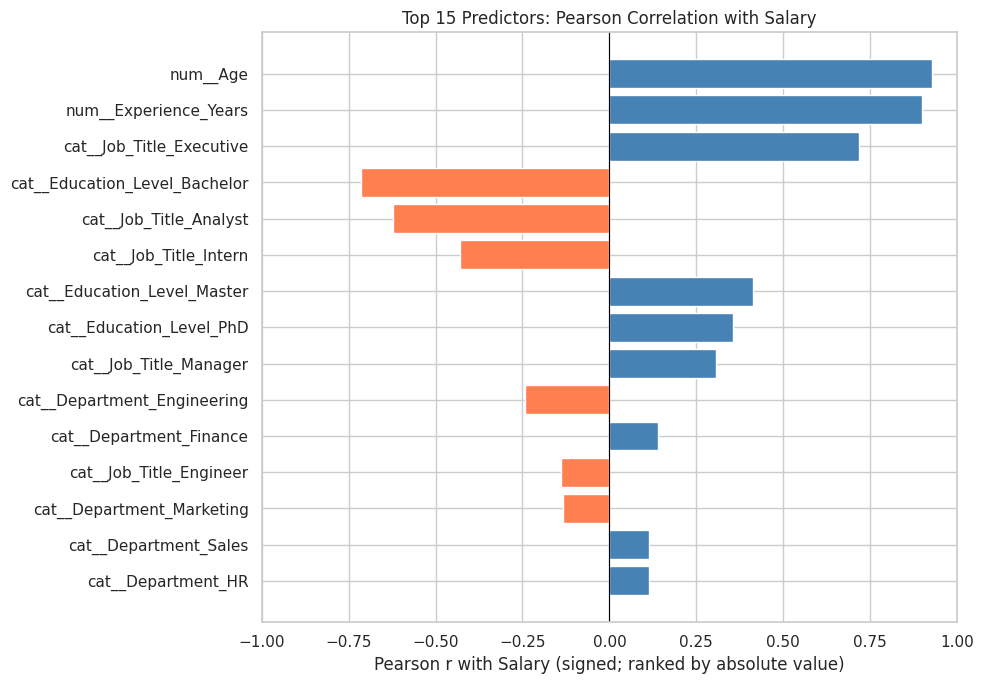

Positive r: higher values/category membership are associated with higher salary.
Negative r: associated with lower salary. Neither direction establishes causation.
For category indicators, the comparison is that category versus all other categories.


In [ ]:
pearson_ranking = selector.pearson_table_.copy()
print('All transformed predictors ranked by absolute Pearson correlation:')
display(pearson_ranking.round(4))

top_corr = pearson_ranking.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if value >= 0 else 'coral' for value in top_corr['Pearson_r']]
ax.barh(top_corr['Feature'], top_corr['Pearson_r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel('Pearson r with Salary (signed; ranked by absolute value)')
ax.set_title('Top 15 Predictors: Pearson Correlation with Salary')
plt.tight_layout()
plt.show()

print('Positive r: higher values/category membership are associated with higher salary.')
print('Negative r: associated with lower salary. Neither direction establishes causation.')
print('For category indicators, the comparison is that category versus all other categories.')

### 4.2 Random Forest feature importance

All transformed predictors ranked by Random Forest importance:


,RF_Rank,Feature,RF_Importance
0,1,num__Age,0.753796
1,2,cat__Job_Title_Executive,0.171065
2,3,cat__Job_Title_Intern,0.036484
3,4,cat__Job_Title_Analyst,0.018919
4,5,cat__Job_Title_Manager,0.007554
5,6,cat__Job_Title_Engineer,0.006490
6,7,num__Experience_Years,0.002388
7,8,cat__Gender_Female,0.000312
8,9,cat__Location_Austin,0.000302
9,10,cat__Gender_Male,0.000298


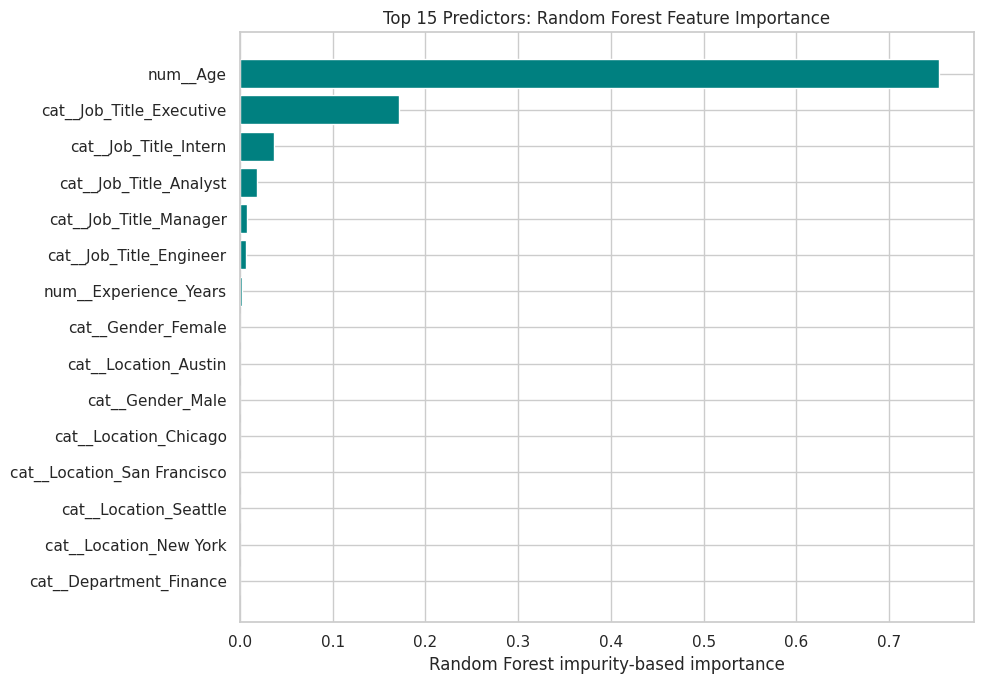

These scores describe this fitted forest, not independent or causal salary effects.
Correlated Age and Experience can share or compete for importance.


In [ ]:
importance_table = selector.rf_table_.copy()
print('All transformed predictors ranked by Random Forest importance:')
display(importance_table.round(6))

top_rf = importance_table.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_rf['Feature'], top_rf['RF_Importance'], color='teal')
ax.set_xlabel('Random Forest impurity-based importance')
ax.set_title('Top 15 Predictors: Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print('These scores describe this fitted forest, not independent or causal salary effects.')
print('Correlated Age and Experience can share or compete for importance.')

### 4.3 Final feature-selection decision

In [ ]:
decision_table = selector.decision_table_.copy()
display(decision_table.round({'Pearson_r': 4, 'Absolute_r': 4, 'RF_Importance': 6}))

selected_features = selector.selected_features_
X_train = selector.transform(X_train_processed)
X_test = selector.transform(X_test_processed)

print('Top-15 overlap from both rankings:')
print(selector.common_features_)
print('Retained original predictors:', ', '.join(selector.retained_variables_))
print(f'Retained {len(selected_features)} of {len(feature_names)} encoded/numeric features.')
print('Selected model-input columns:')
for name in selected_features:
    print(' -', name)
print('Training shape:', X_train.shape, '| Test shape:', X_test.shape)

hr_meaning = {
    'Age': 'Overlapping career-stage signal; strongly correlated with experience and not a causal pay rule.',
    'Experience_Years': 'Relevant experience is a core salary-benchmarking variable.',
    'Job_Title': 'Different roles have different responsibilities and pay bands.',
    'Department': 'May capture function-specific pay patterns; retained only if supported by overlap.',
    'Education_Level': 'May capture qualifications; retained only if supported by overlap.',
    'Location': 'May capture geographic pay differences; retained only if supported by overlap.'
}
print('HR interpretation of retained predictors:')
for name in selector.retained_variables_:
    print(f'{name}: {hr_meaning[name]}')
print('Exclusions from the prediction model:')
for name in sorted(set(X_train_raw.columns) - set(selector.retained_variables_)):
    reason = 'sensitive attribute reserved for descriptive auditing' if name == 'Gender' else 'not retained by the combined rule'
    print(f'{name}: {reason}. This does not prove the variable is irrelevant in real organizations.')

,Pearson_Rank,Feature,Pearson_r,Absolute_r,RF_Rank,RF_Importance,Original_Predictor,In_both_top15,Retained,Decision_Reason
0,1,num__Age,0.9277,0.9277,1,0.753796,Age,True,True,Retained: supported by both rankings
1,2,num__Experience_Years,0.8979,0.8979,7,0.002388,Experience_Years,True,True,Retained: supported by both rankings
2,3,cat__Job_Title_Executive,0.7184,0.7184,2,0.171065,Job_Title,True,True,Retained: supported by both rankings
3,4,cat__Education_Level_Bachelor,-0.7156,0.7156,22,0.000064,Education_Level,False,False,Excluded: no top-15 agreement and no core HR exception
4,5,cat__Job_Title_Analyst,-0.6220,0.6220,4,0.018919,Job_Title,True,True,Retained: supported by both rankings
5,6,cat__Job_Title_Intern,-0.4308,0.4308,3,0.036484,Job_Title,True,True,Retained: supported by both rankings
6,7,cat__Education_Level_Master,0.4132,0.4132,21,0.000126,Education_Level,False,False,Excluded: no top-15 agreement and no core HR exception
7,8,cat__Education_Level_PhD,0.3549,0.3549,23,0.000053,Education_Level,False,False,Excluded: no top-15 agreement and no core HR exception
8,9,cat__Job_Title_Manager,0.3055,0.3055,5,0.007554,Job_Title,True,True,Retained: supported by both rankings
9,10,cat__Department_Engineering,-0.2422,0.2422,20,0.000140,Department,False,True,Retained: complete category group supported by overlap


Top-15 overlap from both rankings:
['cat__Department_Finance', 'cat__Job_Title_Analyst', 'cat__Job_Title_Engineer', 'cat__Job_Title_Executive', 'cat__Job_Title_Intern', 'cat__Job_Title_Manager', 'num__Age', 'num__Experience_Years']
Retained original predictors: Age, Department, Experience_Years, Job_Title
Retained 13 of 23 encoded/numeric features.
Selected model-input columns:
 - num__Age
 - num__Experience_Years
 - cat__Department_Engineering
 - cat__Department_Finance
 - cat__Department_HR
 - cat__Department_Marketing
 - cat__Department_Product
 - cat__Department_Sales
 - cat__Job_Title_Analyst
 - cat__Job_Title_Engineer
 - cat__Job_Title_Executive
 - cat__Job_Title_Intern
 - cat__Job_Title_Manager
Training shape: (8000, 13) | Test shape: (2000, 13)
HR interpretation of retained predictors:
Age: Overlapping career-stage signal; strongly correlated with experience and not a causal pay rule.
Department: May capture function-specific pay patterns; retained only if supported by overlap.

**Decision summary:** The table shows both statistical rankings and the reason for
every retention or exclusion. Unlike simply selecting every high-correlation feature,
the decision also preserves complete category groups and the core role/experience
benchmarks. Removing names/IDs prevents identity-based prediction; excluding gender
does not by itself guarantee fairness because other predictors can act as proxies.

**Validation safeguard:** The fitted selector above is for the training-data tables
and explanations. Each model below uses a pipeline that refits imputation, encoding,
scaling, Pearson ranking, and Random Forest selection separately inside each training
fold. Thus validation rows do not help choose their own predictors.

---
## 5. Model Building and Comparison

Five regression algorithms are trained:

| Model | Justification |
|---|---|
| Linear Regression | Transparent and interpretable baseline |
| Decision Tree | Captures nonlinear rules and interactions |
| Random Forest | Reduces single-tree variance through ensembling |
| Gradient Boosting | Sequentially corrects prediction errors |
| Support Vector Regression | Flexible nonlinear model after scaling |

All models use the identical held-out test set for a fair comparison.

Each model has its own training cell, five-metric results table, train/test R²,
actual-versus-predicted graph, and numerical interpretation, following the faculty's
layout. Gradient Boosting is retained as an
additional comparator. All individual prediction plots use identical axis limits.

Five-fold **training CV RMSE**, not test scores, is the prespecified model-selection
criterion. Test metrics are displayed for reporting, but do not decide the winner
or change the parameter search. CV scores used during selection are development
estimates; the held-out test provides the final assessment of the selected model.


In [ ]:
# 5.1 Evaluation helper containing every regression metric required in the brief
def regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    nonzero = np.asarray(y_true) != 0
    mape = np.mean(np.abs((np.asarray(y_true)[nonzero] - np.asarray(y_pred)[nonzero]) /
                          np.asarray(y_true)[nonzero])) * 100
    return {
        'Model': model_name,
        'MAE': mae,
        'MAPE (%)': mape,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }


# Pipelines keep preprocessing and feature selection inside every CV fold.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def make_pipeline(estimator):
    return Pipeline([
        ('preprocess', clone(preprocessor)),
        ('select', HRFeatureSelector(random_state=RANDOM_STATE)),
        ('model', estimator)
    ])

baseline_results = []
baseline_predictions = {}
fitted_models = {}
development_scores = {}
cv_details = {}

# Display limits only; these values are never inputs to fitting or model selection.
plot_margin = 0.05 * (y.max() - y.min())
salary_plot_limits = (float(y.min() - plot_margin), float(y.max() + plot_margin))

def show_individual_model(name, model, predictions, color):
    metrics = regression_metrics(y_test, predictions, name)
    display(pd.DataFrame([metrics]).round(4))
    train_r2 = model.score(X_train_raw, y_train)
    test_r2 = metrics['R2']
    print(f'Training R²: {train_r2:.4f}')
    print(f'Test R²: {test_r2:.4f}')
    print(f'Train-test R² gap: {train_r2 - test_r2:.4f}')

    fig, ax = plt.subplots(figsize=(6.6, 6))
    ax.scatter(y_test, predictions, alpha=0.3, s=20, color=color, label='Test employees')
    ax.plot(salary_plot_limits, salary_plot_limits, 'r--', label='Perfect prediction')
    ax.set_xlim(salary_plot_limits)
    ax.set_ylim(salary_plot_limits)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1000:g}k'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1000:g}k'))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Actual Salary')
    ax.set_ylabel('Predicted Salary')
    ax.set_title(f'{name}: Actual vs Predicted Salary', fontsize=11)
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f'Interpretation: typical absolute error (MAE) = {metrics["MAE"]:,.2f} salary units;')
    print(f'MAPE = {metrics["MAPE (%)"]:.2f}%; R² = {test_r2:.4f}. R² is not prediction accuracy.')
    print('Closer to the dashed line means smaller errors; above it means overprediction.')
    print('A larger positive train-test R² gap suggests greater overfitting.')
    return metrics

def fit_individual_model(name, estimator, color):
    model = make_pipeline(estimator)
    scores = cross_validate(
        model, X_train_raw, y_train, cv=cv, n_jobs=2,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
    )
    cv_details[name] = scores
    development_scores[name] = float(-scores['test_rmse'].mean())
    model.fit(X_train_raw, y_train)
    predictions = model.predict(X_test_raw)
    fitted_models[name] = model
    baseline_predictions[name] = predictions
    baseline_results.append(show_individual_model(name, model, predictions, color))
    print(f'Five-fold training CV RMSE: {development_scores[name]:,.2f}')
    return model

print('Evaluation, plotting, and pipeline helpers ready.')

Evaluation, plotting, and pipeline helpers ready.


### 5.1 Linear Regression

Interpretable linear baseline. Correlated predictors and complete dummy groups make individual coefficients non-unique or unstable; do not infer causal salary effects.

,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Linear Regression,3414.2339,3.6919,1.811217e+07,4255.84,0.9914


Training R²: 0.9911
Test R²: 0.9914
Train-test R² gap: -0.0003


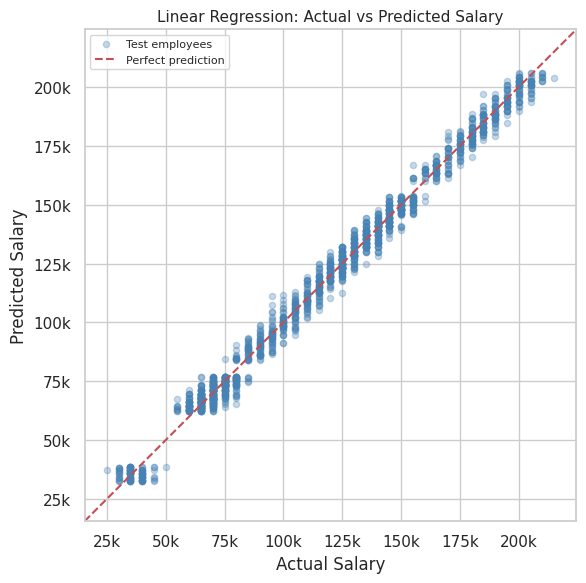

Interpretation: typical absolute error (MAE) = 3,414.23 salary units;
MAPE = 3.69%; R² = 0.9914. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.
Five-fold training CV RMSE: 4,361.11


In [ ]:
# Train, evaluate, and display an individual graph for Linear Regression
linreg = fit_individual_model(
    'Linear Regression', LinearRegression(), 'steelblue'
)

### 5.2 Decision Tree

Captures rule-based interactions. Inspect the train-test gap; tuning can reduce overfitting but improvement is not guaranteed.

,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Decision Tree,3497.2342,3.6666,1.919530e+07,4381.2445,0.9909


Training R²: 0.9920
Test R²: 0.9909
Train-test R² gap: 0.0011


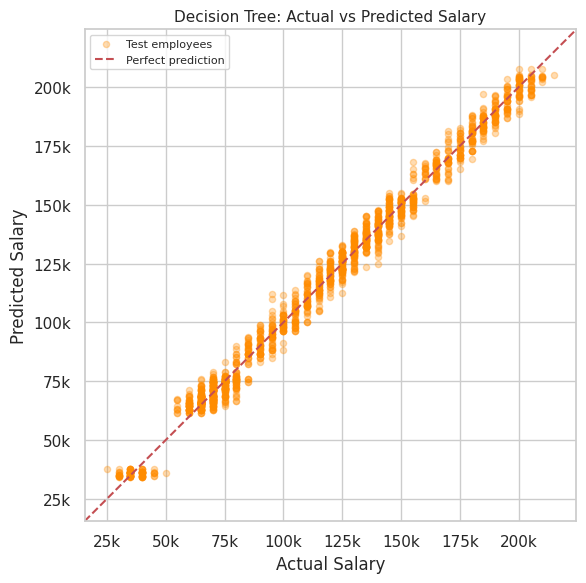

Interpretation: typical absolute error (MAE) = 3,497.23 salary units;
MAPE = 3.67%; R² = 0.9909. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.
Five-fold training CV RMSE: 4,487.05


In [ ]:
# Train, evaluate, and display an individual graph for Decision Tree
dt = fit_individual_model(
    'Decision Tree', DecisionTreeRegressor(random_state=RANDOM_STATE), 'darkorange'
)

### 5.3 Random Forest

Averages many trees to reduce variance. Compare error and generalization, not training fit alone.

,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Random Forest,3497.4134,3.6658,1.914539e+07,4375.5444,0.9909


Training R²: 0.9920
Test R²: 0.9909
Train-test R² gap: 0.0011


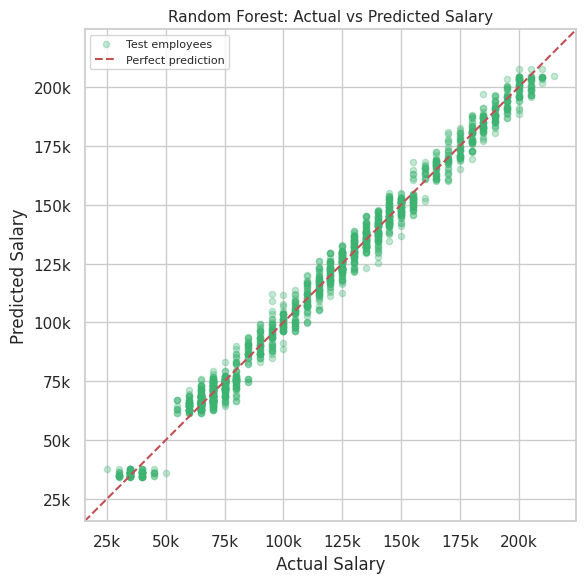

Interpretation: typical absolute error (MAE) = 3,497.41 salary units;
MAPE = 3.67%; R² = 0.9909. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.
Five-fold training CV RMSE: 4,471.49


In [ ]:
# Train, evaluate, and display an individual graph for Random Forest
rf = fit_individual_model(
    'Random Forest', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1), 'mediumseagreen'
)

### 5.4 Support Vector Regression

Nonlinear baseline using scaled predictors. This C/epsilon setting is not extensively tuned; the ranking is not a verdict on every possible SVR.

,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Support Vector Regression,7549.9261,9.7592,1.290819e+08,11361.4204,0.9388


Training R²: 0.9365
Test R²: 0.9388
Train-test R² gap: -0.0023


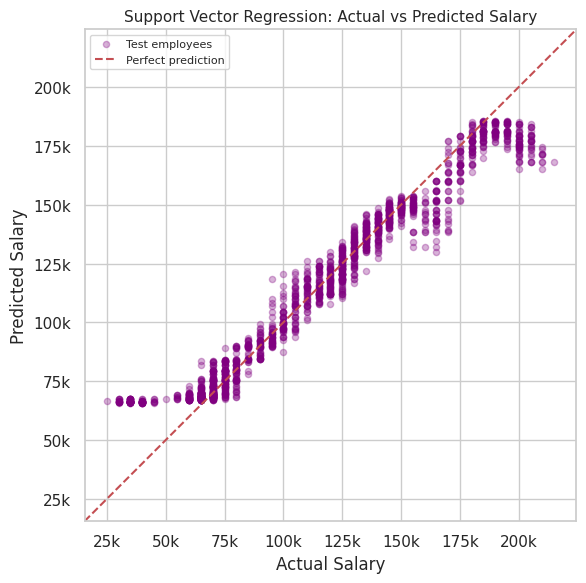

Interpretation: typical absolute error (MAE) = 7,549.93 salary units;
MAPE = 9.76%; R² = 0.9388. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.
Five-fold training CV RMSE: 13,600.23


In [ ]:
# Train, evaluate, and display an individual graph for Support Vector Regression
svm_model = fit_individual_model(
    'Support Vector Regression', SVR(kernel='rbf', C=100, epsilon=0.1), 'purple'
)

### 5.5 Gradient Boosting

Builds trees sequentially to improve predictions; keep it distinct from the four faculty-sample algorithms.

,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Gradient Boosting,3420.4554,3.6081,1.811230e+07,4255.8551,0.9914


Training R²: 0.9913
Test R²: 0.9914
Train-test R² gap: -0.0001


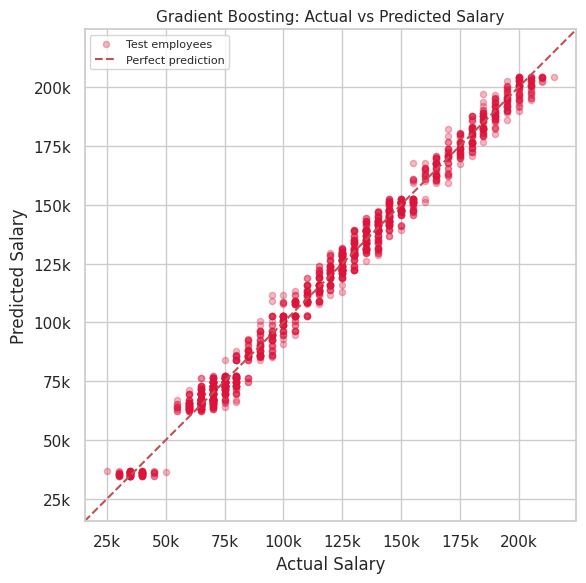

Interpretation: typical absolute error (MAE) = 3,420.46 salary units;
MAPE = 3.61%; R² = 0.9914. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.
Five-fold training CV RMSE: 4,366.49


In [ ]:
# Train, evaluate, and display an individual graph for Gradient Boosting
gb_model = fit_individual_model(
    'Gradient Boosting', GradientBoostingRegressor(random_state=RANDOM_STATE), 'crimson'
)

### 5.6 Baseline comparison

In [ ]:
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df['Training_CV_RMSE'] = baseline_results_df['Model'].map(development_scores)
baseline_results_df = baseline_results_df.sort_values('Training_CV_RMSE').reset_index(drop=True)
display(baseline_results_df.round(4))
print('Ranked by training CV RMSE, not test performance.')

,Model,MAE,MAPE (%),MSE,RMSE,R2,Training_CV_RMSE
0,Linear Regression,3414.2339,3.6919,1.811217e+07,4255.8400,0.9914,4361.1114
1,Gradient Boosting,3420.4554,3.6081,1.811230e+07,4255.8551,0.9914,4366.4928
2,Random Forest,3497.4134,3.6658,1.914539e+07,4375.5444,0.9909,4471.4944
3,Decision Tree,3497.2342,3.6666,1.919530e+07,4381.2445,0.9909,4487.0548
4,Support Vector Regression,7549.9261,9.7592,1.290819e+08,11361.4204,0.9388,13600.2328


Ranked by training CV RMSE, not test performance.


In [ ]:
# 5.7 Compare training and test R-squared to diagnose overfitting
fit_comparison = []
for name, model in fitted_models.items():
    fit_comparison.append({
        'Model': name,
        'Train_R2': model.score(X_train_raw, y_train),
        'Test_R2': model.score(X_test_raw, y_test),
        'Gap': model.score(X_train_raw, y_train) - model.score(X_test_raw, y_test)
    })

fit_comparison_df = pd.DataFrame(fit_comparison).sort_values('Test_R2', ascending=False)
display(fit_comparison_df.round({'Train_R2': 4, 'Test_R2': 4, 'Gap': 4}))

,Model,Train_R2,Test_R2,Gap
0,Linear Regression,0.9911,0.9914,-0.0003
4,Gradient Boosting,0.9913,0.9914,-0.0001
2,Random Forest,0.9920,0.9909,0.0011
1,Decision Tree,0.9920,0.9909,0.0011
3,Support Vector Regression,0.9365,0.9388,-0.0023


### Metric interpretation

- **MAE:** Typical absolute salary error; easiest to explain to HR managers.
- **MAPE:** Average error as a percentage of actual salary.
- **MSE:** Squares errors, strongly penalizing large mistakes.
- **RMSE:** Error in salary units, with more weight on large mistakes.
- **R-squared:** Proportion of salary variation explained by the predictors; higher is better.

The best model should combine low MAE/RMSE/MAPE, high R-squared, and a reasonable train-test gap. A high training score alone may indicate overfitting.

---
## 6. Model Optimization

Decision Tree and Random Forest are optimized because their performance depends strongly on hyperparameters. `RandomizedSearchCV` efficiently tests combinations using 5-fold cross-validation on the training set. The test set remains untouched until final evaluation.



In [ ]:
# 6.1 Set up reproducible 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Tune Decision Tree
dt_search_space = {
    'max_depth': [None, 3, 5, 8, 12, 16, 20],
    'min_samples_split': randint(2, 25),
    'min_samples_leaf': randint(1, 15),
    'max_features': [None, 'sqrt', 'log2']
}

dt_search = RandomizedSearchCV(
    estimator=make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    param_distributions={'model__' + k: v for k, v in dt_search_space.items()},
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=0
)
dt_search.fit(X_train_raw, y_train)

print('Best Decision Tree parameters:')
print(dt_search.best_params_)
print(f'Best cross-validated RMSE: {-dt_search.best_score_:,.2f}')

Best Decision Tree parameters:
{'model__max_depth': 8, 'model__max_features': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 16}
Best cross-validated RMSE: 4,393.94


In [ ]:
# 6.2 Tune Random Forest
rf_search_space = {
    'n_estimators': randint(120, 401),
    'max_depth': [None, 6, 10, 14, 18, 24],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
    param_distributions={'model__' + k: v for k, v in rf_search_space.items()},
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=0
)
rf_search.fit(X_train_raw, y_train)

print('Best Random Forest parameters:')
print(rf_search.best_params_)
print(f'Best cross-validated RMSE: {-rf_search.best_score_:,.2f}')

Best Random Forest parameters:
{'model__max_depth': 10, 'model__max_features': 0.7, 'model__min_samples_leaf': 8, 'model__min_samples_split': 5, 'model__n_estimators': 271}
Best cross-validated RMSE: 4,371.72


,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Decision Tree (Optimized),3450.6599,3.6244,1.857334e+07,4309.6799,0.9912


Training R²: 0.9916
Test R²: 0.9912
Train-test R² gap: 0.0004


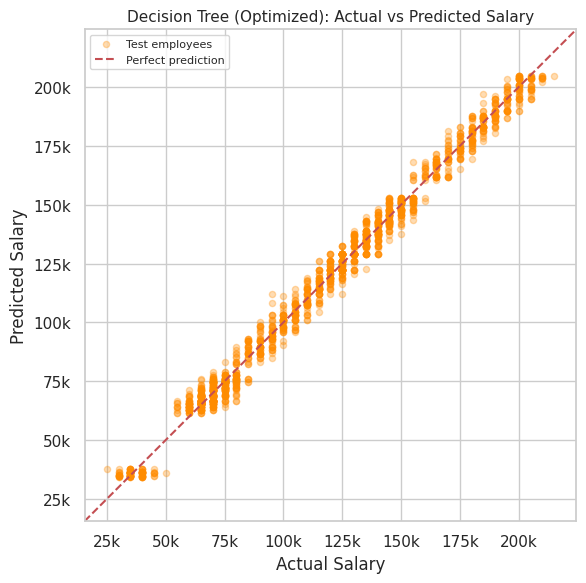

Interpretation: typical absolute error (MAE) = 3,450.66 salary units;
MAPE = 3.62%; R² = 0.9912. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.


,Model,MAE,MAPE (%),MSE,RMSE,R2
0,Random Forest (Optimized),3417.9105,3.6008,1.826255e+07,4273.4704,0.9913


Training R²: 0.9918
Test R²: 0.9913
Train-test R² gap: 0.0005


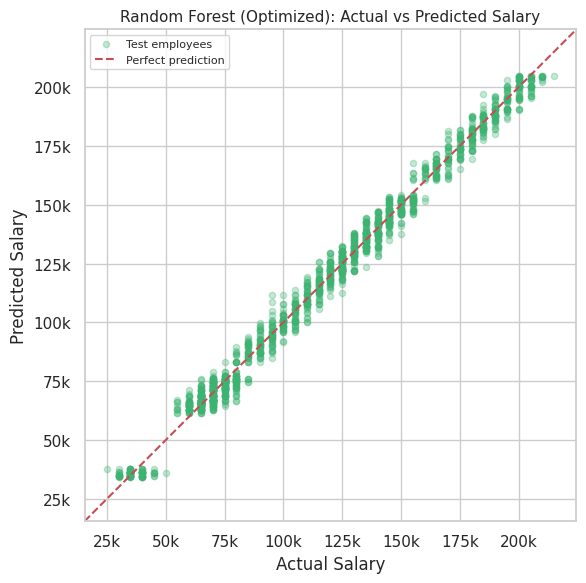

Interpretation: typical absolute error (MAE) = 3,417.91 salary units;
MAPE = 3.60%; R² = 0.9913. R² is not prediction accuracy.
Closer to the dashed line means smaller errors; above it means overprediction.
A larger positive train-test R² gap suggests greater overfitting.


,Model,MAE,MAPE (%),MSE,RMSE,R2,Training_CV_RMSE
0,Decision Tree (Optimized),3450.6599,3.6244,1.857334e+07,4309.6799,0.9912,4393.9374
1,Random Forest (Optimized),3417.9105,3.6008,1.826255e+07,4273.4704,0.9913,4371.7161


In [ ]:
# 6.3 Optimized models: metrics and separate prediction plots
optimized_models = {
    'Decision Tree (Optimized)': dt_search.best_estimator_,
    'Random Forest (Optimized)': rf_search.best_estimator_
}
development_scores.update({
    'Decision Tree (Optimized)': -dt_search.best_score_,
    'Random Forest (Optimized)': -rf_search.best_score_
})
optimized_results = []
optimized_predictions = {}
for (name, model), color in zip(optimized_models.items(), ['darkorange', 'mediumseagreen']):
    predictions = model.predict(X_test_raw)
    optimized_predictions[name] = predictions
    optimized_results.append(show_individual_model(name, model, predictions, color))
optimized_results_df = pd.DataFrame(optimized_results)
optimized_results_df['Training_CV_RMSE'] = optimized_results_df['Model'].map(development_scores)
display(optimized_results_df.round(4))

---
## 7. Model Evaluation and Validation

All baseline and optimized models are now compared using the five required regression metrics. Cross-validation, residual analysis, and actual-vs-predicted plots provide additional validation.

In [ ]:
# 7.1 Select the final model using TRAINING cross-validation only
all_results_df = pd.concat([baseline_results_df, optimized_results_df], ignore_index=True)
all_results_df = all_results_df.sort_values('Training_CV_RMSE').reset_index(drop=True)
all_predictions = {**baseline_predictions, **optimized_predictions}
all_fitted_models = {**fitted_models, **optimized_models}

best_model_name = min(development_scores, key=development_scores.get)
best_model = all_fitted_models[best_model_name]
best_predictions = all_predictions[best_model_name]
display(all_results_df.round(4))
print('Selected using lowest training CV RMSE:', best_model_name)
print('Test metrics describe performance; they were not used for selecting the winner.')

,Model,MAE,MAPE (%),MSE,RMSE,R2,Training_CV_RMSE
0,Linear Regression,3414.2339,3.6919,1.811217e+07,4255.8400,0.9914,4361.1114
1,Gradient Boosting,3420.4554,3.6081,1.811230e+07,4255.8551,0.9914,4366.4928
2,Random Forest (Optimized),3417.9105,3.6008,1.826255e+07,4273.4704,0.9913,4371.7161
3,Decision Tree (Optimized),3450.6599,3.6244,1.857334e+07,4309.6799,0.9912,4393.9374
4,Random Forest,3497.4134,3.6658,1.914539e+07,4375.5444,0.9909,4471.4944
5,Decision Tree,3497.2342,3.6666,1.919530e+07,4381.2445,0.9909,4487.0548
6,Support Vector Regression,7549.9261,9.7592,1.290819e+08,11361.4204,0.9388,13600.2328


Selected using lowest training CV RMSE: Linear Regression
Test metrics describe performance; they were not used for selecting the winner.


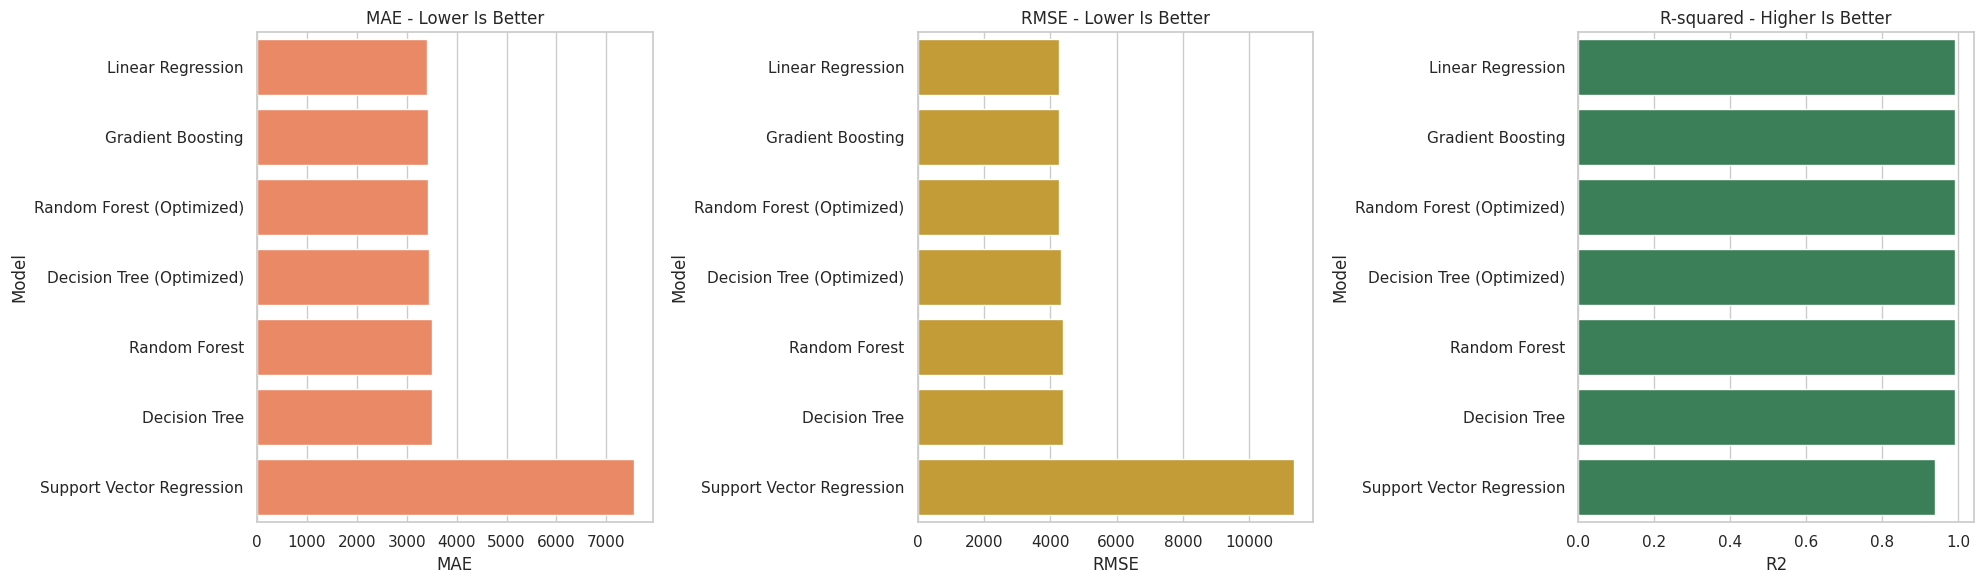

In [ ]:
# 7.2 Visual metric comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_df = all_results_df.copy()

sns.barplot(data=plot_df, y='Model', x='MAE', ax=axes[0], color='coral')
axes[0].set_title('MAE - Lower Is Better')

sns.barplot(data=plot_df, y='Model', x='RMSE', ax=axes[1], color='goldenrod')
axes[1].set_title('RMSE - Lower Is Better')

sns.barplot(data=plot_df, y='Model', x='R2', ax=axes[2], color='seagreen')
axes[2].set_title('R-squared - Higher Is Better')

plt.tight_layout()
plt.show()

In [ ]:
# 7.3 Training cross-validation diagnostics for the selected full pipeline
if best_model_name in cv_details:
    scores = cv_details[best_model_name]
else:
    scores = cross_validate(best_model, X_train_raw, y_train, cv=cv, n_jobs=2,
                            scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'})
cv_rmse = -scores['test_rmse']
cv_r2 = scores['test_r2']
display(pd.DataFrame({'Fold': range(1, 6), 'RMSE': cv_rmse, 'R2': cv_r2}).round(4))
print(f'Mean CV RMSE: {cv_rmse.mean():,.2f} (+/- {cv_rmse.std():,.2f})')
print(f'Mean CV R²: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})')
print('These folds were used in development; this is not independent nested validation.')

,Fold,RMSE,R2
0,1,4333.6432,0.9913
1,2,4437.8629,0.9909
2,3,4351.5878,0.9910
3,4,4402.1199,0.9907
4,5,4280.3433,0.9913


Mean CV RMSE: 4,361.11 (+/- 54.66)
Mean CV R²: 0.9910 (+/- 0.0002)
These folds were used in development; this is not independent nested validation.


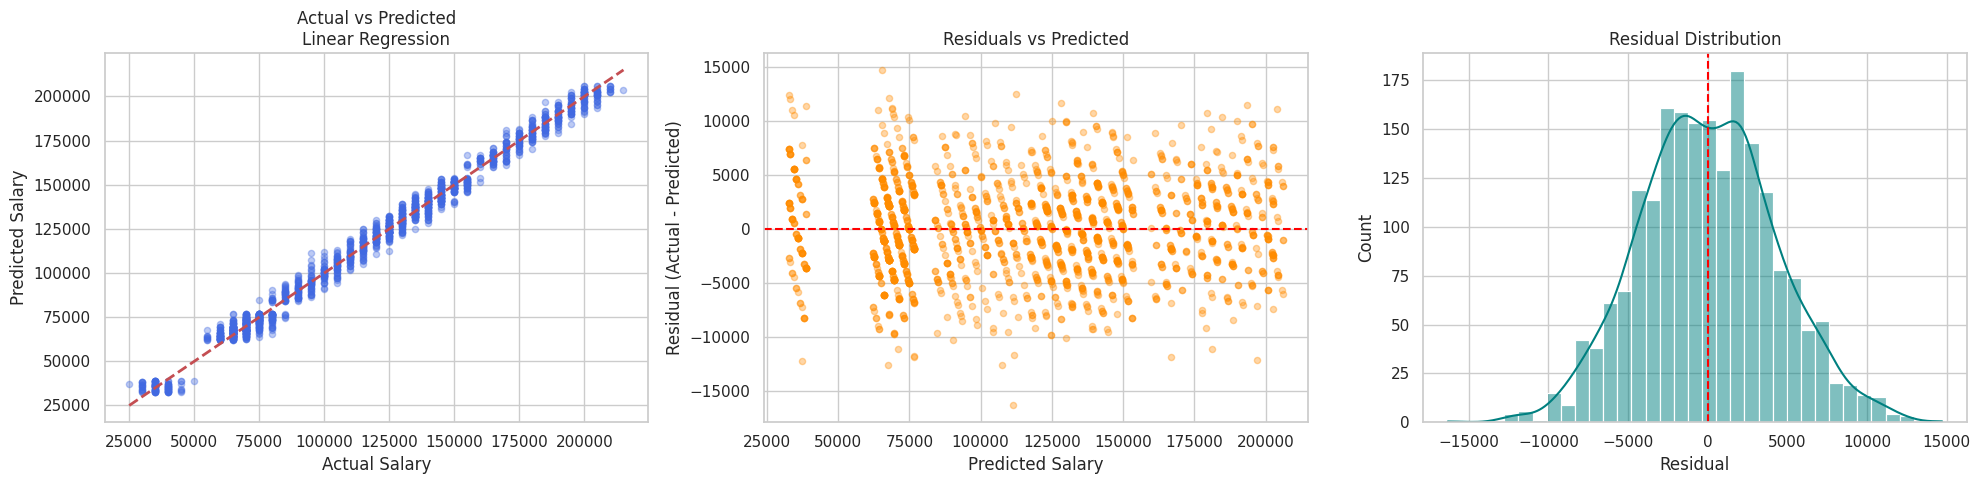

Mean residual: -7.46
Residual standard deviation: 4,255.83


In [ ]:
# 7.4 Actual vs predicted values and residual analysis
residuals = np.asarray(y_test) - np.asarray(best_predictions)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(y_test, best_predictions, alpha=0.35, color='royalblue', s=20)
low = min(y_test.min(), best_predictions.min())
high = max(y_test.max(), best_predictions.max())
axes[0].plot([low, high], [low, high], 'r--', linewidth=2)
axes[0].set_title(f'Actual vs Predicted\n{best_model_name}')
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')

axes[1].scatter(best_predictions, residuals, alpha=0.35, color='darkorange', s=20)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Salary')
axes[1].set_ylabel('Residual (Actual - Predicted)')

sns.histplot(residuals, kde=True, ax=axes[2], color='teal')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():,.2f}')
print(f'Residual standard deviation: {residuals.std():,.2f}')

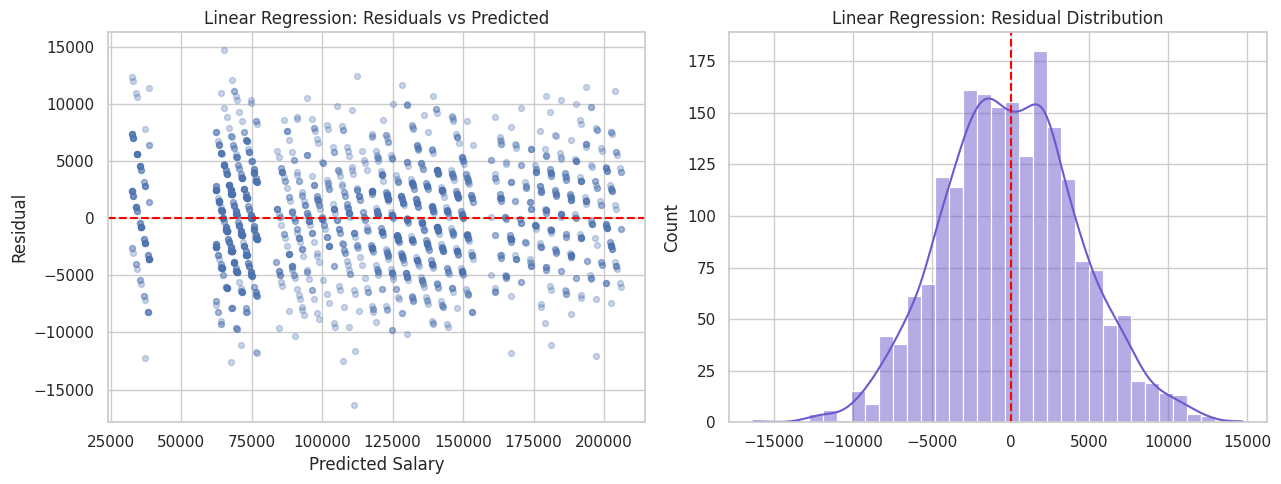

Age-Experience correlation: 0.9823
A strong Age-Experience correlation indicates multicollinearity; predictive accuracy can remain good,
but individual linear coefficients should not be interpreted as independent causal effects.


In [ ]:
# 7.5 Linear Regression diagnostic note (baseline assumptions)
lr_model = fitted_models['Linear Regression']
lr_predictions = baseline_predictions['Linear Regression']
lr_residuals = np.asarray(y_test) - np.asarray(lr_predictions)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(lr_predictions, lr_residuals, alpha=0.3, s=18)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression: Residuals vs Predicted')
axes[0].set_xlabel('Predicted Salary')
axes[0].set_ylabel('Residual')

sns.histplot(lr_residuals, kde=True, ax=axes[1], color='slateblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Linear Regression: Residual Distribution')
plt.tight_layout()
plt.show()

print('Age-Experience correlation:', employee[['Age', 'Experience_Years']].corr().iloc[0, 1].round(4))
print('A strong Age-Experience correlation indicates multicollinearity; predictive accuracy can remain good,')
print('but individual linear coefficients should not be interpreted as independent causal effects.')

,Feature,Importance_Mean,Importance_SD
0,cat__Job_Title_Executive,26504.242,268.704
1,num__Age,15927.049,210.652
2,cat__Job_Title_Intern,12725.028,150.443
3,cat__Job_Title_Analyst,10490.958,147.093
4,cat__Job_Title_Manager,9424.553,112.468
5,num__Experience_Years,2359.572,60.579
6,cat__Job_Title_Engineer,92.159,21.095
7,cat__Department_Engineering,4.578,3.375
8,cat__Department_HR,2.738,1.813
9,cat__Department_Marketing,0.359,0.312


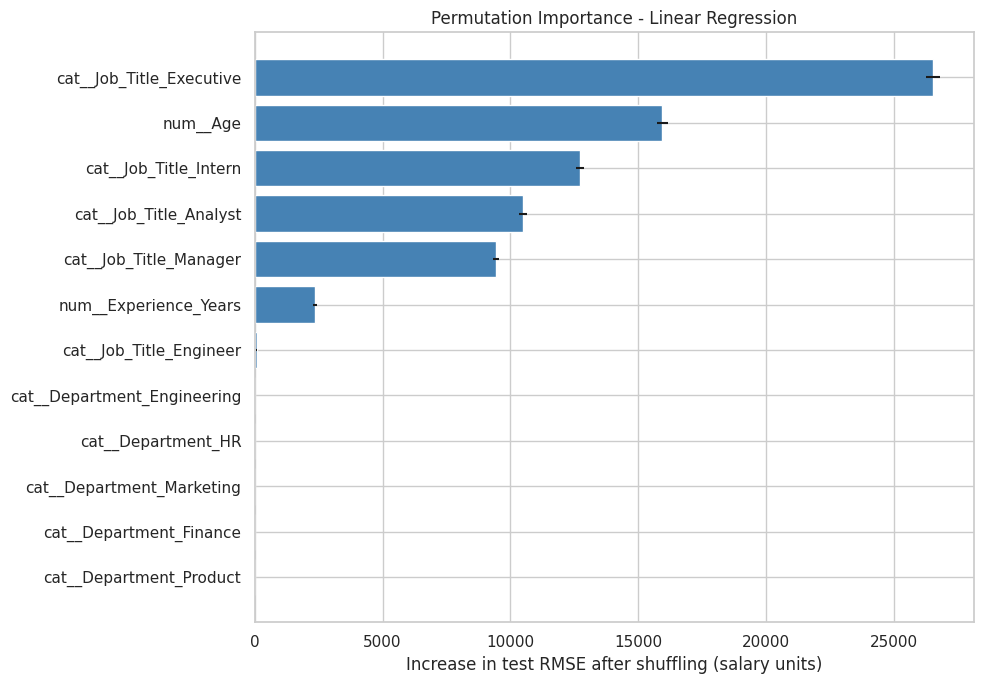

Correlated predictors can hide one another; dummy-wise shuffling can produce unusual category combinations.
This post-fit explanation is not used to reselect features or tune the model.


In [ ]:
# 7.6 Final-model permutation importance, for interpretation only
# Explain the selected encoded predictors of the final fitted pipeline.
best_processed_test = best_model.named_steps['preprocess'].transform(X_test_raw)
best_selected_test = best_model.named_steps['select'].transform(best_processed_test)
best_selected_names = best_model.named_steps['select'].get_feature_names_out()
perm = permutation_importance(
    best_model.named_steps['model'], best_selected_test, y_test,
    scoring='neg_root_mean_squared_error', n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=2
)
final_importance = pd.DataFrame({
    'Feature': best_selected_names, 'Importance_Mean': perm.importances_mean,
    'Importance_SD': perm.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)
display(final_importance.round(3))
plot_imp = final_importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_imp['Feature'], plot_imp['Importance_Mean'], xerr=plot_imp['Importance_SD'], color='steelblue')
ax.set_title(f'Permutation Importance - {best_model_name}')
ax.set_xlabel('Increase in test RMSE after shuffling (salary units)')
plt.tight_layout()
plt.show()
print('Correlated predictors can hide one another; dummy-wise shuffling can produce unusual category combinations.')
print('This post-fit explanation is not used to reselect features or tune the model.')

In [ ]:
# 7.7 Create a sample prediction table and save it for optional submission
prediction_results = X_test_raw.copy()
prediction_results['Actual_Salary'] = np.asarray(y_test)
prediction_results['Predicted_Salary'] = np.round(best_predictions, 2)
prediction_results['Absolute_Error'] = np.round(
    np.abs(prediction_results['Actual_Salary'] - prediction_results['Predicted_Salary']), 2
)
prediction_results = prediction_results.sort_values('Absolute_Error', ascending=False)

display(prediction_results.head(10))
prediction_results.to_csv('employee_salary_predictions.csv', index=False)
print('Saved: employee_salary_predictions.csv')

,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Actual_Salary,Predicted_Salary,Absolute_Error
605,38,Male,Product,Engineer,17,Bachelor,Seattle,95000.0,111314.00,16314.00
5500,24,Female,Marketing,Analyst,1,Master,Seattle,80000.0,65287.68,14712.32
9913,25,Male,HR,Analyst,4,Bachelor,San Francisco,55000.0,67564.95,12564.95
4942,37,Male,Engineering,Engineer,10,PhD,New York,95000.0,107533.70,12533.70
1785,40,Female,Product,Engineer,13,PhD,Austin,125000.0,112548.59,12451.41
5071,21,Male,Engineering,Intern,0,Bachelor,San Francisco,45000.0,32634.50,12365.50
2420,24,Male,Engineering,Intern,1,Bachelor,San Francisco,25000.0,37199.84,12199.84
5359,25,Male,Sales,Analyst,4,Bachelor,Austin,80000.0,67906.48,12093.52
4881,55,Male,Sales,Executive,32,Master,New York,185000.0,197092.61,12092.61
7618,21,Male,Engineering,Intern,1,Bachelor,Seattle,45000.0,33022.13,11977.87


Saved: employee_salary_predictions.csv


---
## 8. Business Insights and Recommendations

### 8.1 Insights

1. **Job-related characteristics are central to salary prediction.** The final decision table identifies exactly which variables are retained; the permutation table explains their contributions to the selected model.
2. **Experience and age show strong positive salary associations.** However, their very high correlation means their effects overlap; neither should be treated as an isolated causal driver.
3. **Job-title pay bands are visibly different.** HR can compare employees within similar roles instead of applying a single company-wide salary benchmark.
4. **Model errors must remain visible.** MAE and MAPE explain practical prediction error, while RMSE highlights larger mistakes that may represent unusual employees or incomplete information.
5. **Recorded gender requires fairness review.** Gender is excluded from prediction and used only for descriptive comparisons; a group mean difference is not evidence that gender should determine salary. HR should compare model errors and pay gaps across groups before operational use.

### 8.2 HR recommendations

- Use the model as a **salary-benchmarking support tool**, not an automatic salary-setting system.
- Investigate employees whose actual salaries differ greatly from predictions; differences may reflect scarce skills, performance, tenure, negotiation, or data-quality issues.
- Build transparent pay bands by job title, experience, education, and location.
- Retrain the model when compensation structures or market conditions change.
- Require HR review before acting on any individual prediction.

### 8.3 Limitations

- The dataset does not include performance ratings, tenure, certifications, working hours, contract type, promotion history, or external market salary data.
- Association does not establish causation.
- High correlation between age and experience reduces coefficient-level interpretability.
- Historical salary data can reproduce existing inequities.
- Random train/test splitting estimates performance on similar records, not necessarily future labor-market conditions.

### 8.4 Future improvements

- Add job grade, performance, tenure, skills, contract type, and market benchmark variables.
- Validate the model on a separate organization or a later time period.
- Compare group-level errors and fairness measures.
- Try additional algorithms such as XGBoost after establishing a strong baseline.
- Deploy only with access control, audit logs, model monitoring, and human oversight.

In [ ]:
# 8.5 Automatically generate a concise executive summary from the actual results
best_row = all_results_df.set_index('Model').loc[best_model_name]
top_three = final_importance.head(3)['Feature'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False).tolist()

print('=' * 78)
print('EMPLOYEE SALARY PREDICTION - EXECUTIVE SUMMARY')
print('=' * 78)
print(f'Rows analyzed                 : {len(employee):,}')
print(f'Final model                  : {best_model_name}')
print(f'Test MAE                     : {best_row["MAE"]:,.2f}')
print(f'Test MAPE                    : {best_row["MAPE (%)"]:.2f}%')
print(f'Test RMSE                    : {best_row["RMSE"]:,.2f}')
print(f'Test R-squared               : {best_row["R2"]:.4f}')
print(f'Mean 5-fold CV RMSE          : {cv_rmse.mean():,.2f}')
print(f'Top three predictive signals: {", ".join(top_three)}')
print('\nDecision guidance: Use predictions as compensation benchmarks with HR review,')
print('fairness checks, and additional employee-performance and market-pay information.')

EMPLOYEE SALARY PREDICTION - EXECUTIVE SUMMARY
Rows analyzed                 : 10,000
Final model                  : Linear Regression
Test MAE                     : 3,414.23
Test MAPE                    : 3.69%
Test RMSE                    : 4,255.84
Test R-squared               : 0.9914
Mean 5-fold CV RMSE          : 4,361.11
Top three predictive signals: Job_Title_Executive, Age, Job_Title_Intern

Decision guidance: Use predictions as compensation benchmarks with HR review,
fairness checks, and additional employee-performance and market-pay information.


---
## 9. Conclusion

This project completed the full predictive-analytics workflow required: data collection, data-quality checks, preprocessing, transformation, EDA, feature selection, multiple regression models, hyperparameter optimization, five required evaluation metrics, cross-validation, residual analysis, and HR-focused recommendations.

The final model is selected programmatically using the lowest five-fold training cross-validation RMSE. The held-out test is used to report MAE, MAPE, MSE, RMSE, and R-squared, not to select the model. The result demonstrates how HR analytics can provide a consistent salary benchmark while also showing why human review, richer organizational data, and fairness testing remain necessary.

